# Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from sklearn.decomposition import PCA

VARIANCE_PERCENTILE_THRESHOLD = 10   # features with var < this are dropped
MAHAL_ALPHA        = 0.001  # chi² significance level for outlier cutoff# (smaller = less aggressive removal)
PRELIM_MAX_ITER    = 1000

# Load datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (886, 12044)
Test shape: (379, 12043)


,id,cancer,RNF14,UBE2Q1,RNF17,RNF10,RNF11,RNF13,REM1,TSKS,...,SELE,SLC7A10,SLC7A11,FOLR1,NPY5R,GNGT1,PTRF,SERPINH1,NFIX,SELP
0,S8886438,1,8.130644,8.869802,4.355382,6.882796,9.170429,9.695898,4.609017,4.123772,...,3.884740,4.363119,5.565958,3.951505,3.849734,4.209866,8.519448,7.921267,5.662386,4.152534
1,S1818761,3,5.502858,8.791778,3.729482,6.556056,8.262384,7.596577,4.263336,3.008913,...,2.917661,3.249593,4.446910,9.439381,3.248632,3.221614,6.413054,8.645957,3.475170,3.074514
2,S2937758,1,7.537196,9.220189,4.354501,7.368029,9.307845,8.833408,4.707772,3.909128,...,3.837739,4.129411,5.789456,4.037472,3.716405,3.828743,7.160989,7.874510,5.672849,4.426313
3,S3008005,3,7.014867,9.453761,3.702113,5.985680,9.008926,7.947574,5.470811,3.107538,...,2.709770,3.438689,6.110492,8.970555,3.229985,3.367337,4.686543,7.726071,3.387412,3.314188
4,S2869276,1,8.169815,9.402682,4.062033,7.555819,9.717518,10.628858,4.926767,3.746619,...,3.483991,3.734450,6.275364,4.134837,3.966953,3.450866,7.012476,7.292837,7.488271,4.061273


# Separate Features and Target

In [2]:
X = train.drop(columns=["id", "cancer"])
y = train["cancer"]

X_test = test.drop(columns=["id"])

# Low Variance Feature Removal
    - Fit train data only, and then transform both
    - Using VarianceThreshold
    - Since data is log-transformed use small threshold like 0.01
    - We removed near-zero variance genes to reduce noise and improve model stability in the high-dimensional setting.

In [3]:
variances = X.var()

print(variances.describe())

count    12042.000000
mean         0.830792
std          1.061677
min          0.052552
25%          0.292792
50%          0.525417
75%          0.904438
max         19.023686
dtype: float64


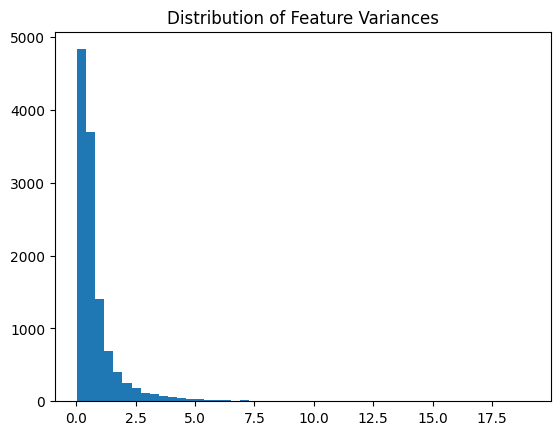

In [4]:
plt.hist(variances, bins=50)
plt.title("Distribution of Feature Variances")
plt.show()

In [5]:
threshold = np.percentile(variances, VARIANCE_PERCENTILE_THRESHOLD)
print(threshold)

0.1655183401077742


In [6]:
selector = VarianceThreshold(threshold=threshold)

# removing 10th percentile

# Fit on training data only

X_var = selector.fit_transform(X)

# Apply same transformation to test
X_test_var = selector.transform(X_test)

print("Original features:", X.shape[1])
print("Remaining features:", X_var.shape[1])

Original features: 12042
Remaining features: 10832


# Noise Detection and Handling

- identification: Samples that simultaneously satisfy the conditions of "extremely far distance" in Mahalanobis distance and "extremely low prediction probability" in preliminary training model are labeled as noise.
- Processing: High-confidence samples are directly relabeled; low-confidence samples are discarded.

##### Scale Features for Mahalanobis & preliminary model

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var)
n_samples = X_scaled.shape[0]

##### Preliminary L2 Multinomial Logistic Regression
used only to generate predicted labels for the noise-detection step

In [8]:
prelim_model = LogisticRegression(solver = "lbfgs",
                                  max_iter = PRELIM_MAX_ITER,
                                  C = 1.0,
                                  random_state = 42,
                                  l1_ratio=0) # penalty = L2)
prelim_model.fit(X_scaled,y)
probs = prelim_model.predict_proba(X_scaled)

In [9]:
# obtain the prediction probability for each observation
label_map = {l: i for i, l in enumerate(prelim_model.classes_)}
given_label_probs = np.array([
    probs[i, label_map[y.iloc[i]]]
    for i in range(n_samples)
])

Mahalanobis Distance

In [10]:
def mahal_distances_for_class_robust(x_class: np.ndarray, variance_threshold = 0.95)->np.ndarray:
    """
    return Mahalanobis distance for each row in X_class from the class centroid
    """
    n_samples, n_features = x_class.shape

    # check to see if it needs dimension reduction
    if n_features >= n_samples:
        max_component = n_samples -1

        pca = PCA(n_components = variance_threshold, svd_solver = "full")

        x_reduced = pca.fit_transform(x_class)

        x_to_use = x_reduced
    else:
        x_to_use = x_class

    mean_vec = x_to_use.mean(axis = 0)
    cov = np.cov(x_to_use, rowvar = False)

    # regularise covariance to avoid singularity
    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        cov_inv = np.linalg.pinv(cov)

    dists = np.array([mahalanobis(row, mean_vec, cov_inv) for row in x_to_use] )
    return dists

In [11]:
# $\chi^2$ critical value: df = number of features
df_chi2 = X_scaled.shape[1]
chi2_cutoff = chi2.ppf(1 - MAHAL_ALPHA, df=df_chi2)
print(f"χ²({df_chi2}, α={MAHAL_ALPHA}) cutoff = {chi2_cutoff:.2f}")

χ²(10832, α=0.001) cutoff = 11292.55
